# Student Academic Risk Prediction System
**Ebi · AI/ML recruitment project**  
Data: `dcs_student_data.csv`, supplied in `studentkaggle.zip`.

## 1. Project Objective
Explore student performance, inspect attendance versus marks, and compare three explainable classifiers for a **rule-defined academic support priority**. Generate individual recommendations and a CSV report.

This is a learning prototype, not a validated intervention system. A working pipeline does not guarantee useful predictions. We will compare against simple baselines and report weak results honestly.

**Run:** In Colab, open this notebook and choose **Run all**; upload the supplied ZIP when prompted. In Jupyter, place the ZIP or extracted CSV beside this notebook and run all cells. No source-code edits are needed. Saved outputs below come from the supplied data.


**Classification** means choosing a category rather than predicting a number. Here the categories are Low, Medium and High academic-support priority. We create historical answers from total scores, train on presumed earlier information, and ask whether those earlier inputs can predict the answers for other students.

There are **two different operations**: the ML model estimates a risk category, while simple rules write study recommendations. Neither confirms a real student's need for intervention. Start with this notebook for the complete project; use `INTERVIEW_GUIDE.md` for slower explanations and interview practice.


## 2. Import Libraries
Pandas handles tables, Matplotlib/Seaborn draw charts, and scikit-learn provides preprocessing and models. A fixed seed makes the split and algorithms reproducible within the same library environment. Package versions are printed because versions can slightly change results.


In [1]:
from pathlib import Path
import io, re, zipfile, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, make_scorer)
from sklearn.inspection import permutation_importance
try:
    from IPython.display import display, Markdown, FileLink
except ImportError:
    # This fallback also lets the analysis execute as ordinary Python.
    if 'display' not in globals():
        def display(value):
            print(value.to_string() if isinstance(value, pd.DataFrame) else value)
    if 'Markdown' not in globals():
        Markdown = str
    if 'FileLink' not in globals():
        FileLink = str

SEED = 42
RISK_ORDER = ['Low', 'Medium', 'High']
RISK_COLORS = ['#34877c', '#ce973a', '#c26161']
sns.set_theme(style='whitegrid', context='notebook', palette=['#347c93'])
plt.rcParams.update({'figure.figsize': (9, 4.5), 'figure.dpi': 120,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'axes.titlesize': 13})
pd.set_option('display.max_columns', 24)
print({'Python': platform.python_version(), 'pandas': pd.__version__,
       'numpy': np.__version__, 'scikit-learn': sklearn.__version__,
       'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__})


{'Python': '3.12.14', 'pandas': '2.2.3', 'numpy': '2.3.5', 'scikit-learn': '1.8.0', 'matplotlib': '3.10.8', 'seaborn': '0.13.2'}


### What the imported libraries do
- **pandas:** reads CSVs and manipulates DataFrame tables.
- **NumPy:** numerical operations, arrays and missing-number markers (`np.nan`).
- **Matplotlib:** draws and labels figures; **Seaborn** provides convenient statistical plotting functions.
- **scikit-learn:** preprocessing, data splitting, classifiers and evaluation.
- **pathlib / zipfile / io:** locate files and read the supplied ZIP in memory. **hashlib:** identifies the source bytes with a fingerprint.
- **IPython display:** shows formatted tables and Markdown inside a notebook; a plain-Python fallback is included for execution outside Jupyter.

`SEED = 42` is our shared reproducibility setting. Plot settings affect appearance, not the model. We print package versions because results can change slightly with different software versions.


## 3. Load Dataset
Read the CSV directly from the ZIP without extracting arbitrary archive paths. We prefer the known filename and validate its schema. Minor differences in capitalization, spaces and underscores are normalized to the verified column names. If several matching datasets exist, the loader asks which to use.


**Read the loader:** `Path` locates the supplied file; `ZipFile` opens the ZIP; `archive.read(name)` reads the CSV bytes; `pd.read_csv(...)` turns them into a table called a **DataFrame**. `normalize_columns` makes small naming differences consistent. The SHA-256 fingerprint lets us identify the exact CSV used. CSV contents are never executed as code.

The loader searches the notebook's working folder and common upload folders, then offers a Colab upload or a local file-path prompt. It checks required columns rather than blindly picking the first CSV. The supplied ZIP contains one CSV.


In [2]:
EXPECTED = ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
            'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
            'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
            'Projects_Score', 'Total_Score', 'Grade', 'test_preparation_course',
            'math_score', 'reading_score', 'writing_score', 'science_score']
def key(name):
    return re.sub(r'[^a-z0-9]', '', str(name).lower())
COLUMN_MAP = {key(c): c for c in EXPECTED}
COLUMN_MAP.update({'attendance': 'Attendance (%)', 'attendancepercent': 'Attendance (%)',
                   'attendancerate': 'Attendance (%)', 'totalscore': 'Total_Score'})
def normalize_columns(frame):
    frame = frame.rename(columns=lambda c: COLUMN_MAP.get(key(c), str(c).strip()))
    if frame.columns.duplicated().any():
        raise ValueError('Two input columns resolve to the same name; check the dataset.')
    return frame

def load_dataset():
    locations = [Path.cwd(), Path.cwd() / 'upload', Path.cwd().parent / 'upload', Path('/content')]
    paths = []
    for folder in locations:
        for filename in ['dcs_student_data.csv', 'studentkaggle.zip']:
            p = folder / filename
            if p.is_file() and p.resolve() not in paths:
                paths.append(p.resolve())
    if not paths:
        try:
            from google.colab import files
            print('Upload studentkaggle.zip or dcs_student_data.csv.')
            uploaded = files.upload()
            paths = [Path(name) for name in uploaded if Path(name).suffix.lower() in ['.zip', '.csv']]
        except ImportError:
            paths = [Path(input('Path to the supplied ZIP or CSV: ').strip().strip('"'))]
    candidates = []
    for path in paths:
        if path.suffix.lower() == '.zip':
            with zipfile.ZipFile(path) as archive:
                for name in archive.namelist():
                    if name.lower().endswith('.csv'):
                        candidates.append((f'{path.name} / {name}', archive.read(name)))
        elif path.suffix.lower() == '.csv':
            candidates.append((path.name, path.read_bytes()))
    valid, seen = [], set()
    for name, data in candidates:
        digest = hashlib.sha256(data).hexdigest()
        frame = normalize_columns(pd.read_csv(io.BytesIO(data)))
        required = {'Student_ID', 'Attendance (%)', 'Total_Score', 'Midterm_Score',
                    'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Department'}
        if required.issubset(frame.columns) and digest not in seen:
            valid.append((name, digest, frame))
            seen.add(digest)
    if not valid:
        raise ValueError('No CSV with the required student-performance columns was found.')
    choice = 0
    if len(valid) > 1:
        for i, (name, _, frame) in enumerate(valid):
            print(i, name, frame.shape)
        choice = int(input('Select dataset number: '))
    return valid[choice]

source_name, source_sha256, raw = load_dataset()
print('Source:', source_name)
print('CSV SHA-256:', source_sha256)
print('Rows and columns:', raw.shape)
print('Exact columns:', raw.columns.tolist())


Source: studentkaggle.zip / dcs_student_data.csv
CSV SHA-256: fb6cfb64e8692bcd9734a4588e08d3bafcb2696072f7bf3c835041b12ebc3079
Rows and columns: (10030, 21)
Exact columns: ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score']


## 4. Understand the Columns and Inspect the Dataset
Preview only non-identifying fields. Names, email addresses and student IDs are not displayed here. Numerical ranges are inspected before assigning validation rules. `math_score` initially looks categorical because one entry contains a literal escaped tab.


| Actual column | Meaning / observed type | Model input? | Reason |
|---|---|---|---|
| Student_ID | Student identifier; text | No | Identity is not evidence of academic performance; used only to check duplicate students. |
| First_Name | Given name; text | No | Unnecessary personal identifier. |
| Last_Name | Family name; text | No | Unnecessary personal identifier. |
| Email | Email address; text | No | Unnecessary personal identifier. |
| Gender | Recorded category; text | No | Not needed for the academic-input demonstration; exclusion alone does not guarantee fairness. |
| Age | Recorded age; numeric with missing/invalid values | No | Not needed; one negative value is invalid and 87 is unusual but possible. |
| Department | Subject department; text | Yes | Academic context; one-hot encode, not a ranking. |
| Attendance (%) | Attendance percentage; numeric | Yes | Possible engagement indicator, available before the final outcome only by assumption. |
| Midterm_Score | Midterm mark; numeric | Yes | An intermediate assessment. |
| Final_Score | Final examination mark; numeric | No | Final outcome; would not be available for an early warning. |
| Assignments_Avg | Assignment average; numeric | Yes | Assumed to be accumulated by the intervention checkpoint. |
| Quizzes_Avg | Quiz average; numeric | Yes | Assumed to be accumulated by the intervention checkpoint. |
| Participation_Score | Class participation score, observed 0–10; numeric | Yes | Another academic engagement measure. |
| Projects_Score | Project assessment mark; numeric | No | Timing of project completion is undocumented. |
| Total_Score | Overall academic score; numeric | No | Defines Risk_Level, so using it would reveal the answer. |
| Grade | Letter grade; text | No | Final outcome; also inconsistent with the observed total-score bands. |
| test_preparation_course | Binary 0/1 code | No | Exact coding meaning and timing are not documented. |
| math_score | Mathematics mark; initially text | No | Assessment timing is unknown; a literal escaped tab is cleaned. |
| reading_score | Reading mark; numeric | No | Assessment timing is unknown. |
| writing_score | Writing mark; numeric | No | Assessment timing is unknown. |
| science_score | Science mark; numeric | No | Assessment timing is unknown. |

Meanings are inferred from the supplied column names, not a verified data dictionary. Most scores are provisionally treated as /100; participation is /10. **A feature is an input; the target is the answer to learn.** The generated target is `Risk_Level`, with values Low, Medium and High.


**The inspection commands:** `head()` previews five rows; `shape` returns `(rows, columns)`; `columns` lists field names; `info()` prints data types and non-missing counts; `describe()` summarizes count, mean, standard deviation, minimum, quartiles and maximum. A quartile divides sorted observations into quarters; the 50% quartile is the median. `isna().sum()` counts blank values, and `duplicated().sum()` counts exact repeated rows. The preview uses `raw[safe_cols].head()` to hide names and email addresses.


In [3]:
private = ['Student_ID', 'First_Name', 'Last_Name', 'Email']
safe_cols = [c for c in raw.columns if c not in private]
display(raw[safe_cols].head())
raw.info()
display(raw.describe().T.round(2))
quality_before = pd.DataFrame({'Data type': raw.dtypes.astype(str),
                              'Missing': raw.isna().sum(),
                              'Distinct values': raw.nunique()})
display(quality_before)
print('Exact duplicate rows:', raw.duplicated().sum())
if not raw.isna().any().any():
    print('No missing values were detected.')
for c in ['Gender', 'Department', 'Grade', 'test_preparation_course']:
    print(c, raw[c].value_counts(dropna=False).to_dict())
print('Non-numeric math entries:', raw.loc[pd.to_numeric(raw['math_score'], errors='coerce').isna(),
                                         'math_score'].map(repr).tolist())
print('Grade versus Total_Score (before cleaning):')
display(raw.groupby('Grade')['Total_Score'].agg(['count', 'min', 'max', 'mean']).round(2))


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,test_preparation_course,math_score,reading_score,writing_score,science_score
0,Female,22.0,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,1,89,38.0,85.0,26.0
1,Male,18.0,Engineering,97.27,97.23,45.80,74.32,94.24,8.32,55.65,50.64,A,0,65,100.0,67.0,96.0
2,Male,24.0,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,0,10,99.0,97.0,58.0
3,Female,24.0,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,1,22,51.0,41.0,84.0
4,Female,23.0,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,1,26,58.0,64.0,65.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10030 entries, 0 to 10029
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10030 non-null  object 
 1   First_Name               10030 non-null  object 
 2   Last_Name                10030 non-null  object 
 3   Email                    10030 non-null  object 
 4   Gender                   10030 non-null  object 
 5   Age                      9829 non-null   float64
 6   Department               10030 non-null  object 
 7   Attendance (%)           9831 non-null   float64
 8   Midterm_Score            9828 non-null   float64
 9   Final_Score              9829 non-null   float64
 10  Assignments_Avg          9830 non-null   float64
 11  Quizzes_Avg              9829 non-null   float64
 12  Participation_Score      9828 non-null   float64
 13  Projects_Score           9830 non-null   float64
 14  Total_Score           

,count,mean,std,min,25%,50%,75%,max
Age,9829.0,20.78,2.00,-3.00,19.00,21.00,22.00,87.00
Attendance (%),9831.0,75.17,14.44,-12.00,62.86,75.32,87.46,135.00
Midterm_Score,9828.0,70.38,17.31,-8.00,55.44,70.61,85.19,145.00
Final_Score,9829.0,69.83,17.31,-5.00,54.86,69.94,84.82,132.00
Assignments_Avg,9830.0,74.95,14.36,50.00,62.54,74.92,87.28,99.98
Quizzes_Avg,9829.0,74.84,14.42,50.03,62.36,74.83,87.34,99.96
Participation_Score,9828.0,5.01,2.90,0.00,2.48,5.03,7.53,10.00
Projects_Score,9830.0,75.29,14.44,50.01,62.81,75.41,87.88,100.00
Total_Score,10030.0,75.03,14.34,50.02,62.83,75.08,87.48,99.99
test_preparation_course,10030.0,0.39,0.49,0.00,0.00,0.00,1.00,1.00


,Data type,Missing,Distinct values
Student_ID,object,0,10000
First_Name,object,0,8
Last_Name,object,0,6
Email,object,0,5000
Gender,object,0,4
Age,float64,201,9
Department,object,0,8
Attendance (%),float64,199,4301
Midterm_Score,float64,202,4858
Final_Score,float64,201,4795


Exact duplicate rows: 30
Gender {'Male': 5018, 'Female': 4832, ' FEMALE ': 90, ' MALE ': 90}
Department {'CS': 3789, 'Engineering': 2830, 'Business': 1927, 'Mathematics': 982, 'Computer Science': 203, ' engineering ': 162, 'BUSINESS': 95, 'Math': 42}
Grade {'A': 2969, 'B': 1960, 'D': 1806, 'F': 1658, 'C': 1637}
test_preparation_course {0: 6141, 1: 3889}
Non-numeric math entries: ["'\\\\t41'"]
Grade versus Total_Score (before cleaning):


,count,min,max,mean
Grade,,,,
A,2969,50.02,99.99,74.63
B,1960,50.04,99.99,75.03
C,1637,50.02,99.98,75.49
D,1806,50.03,99.95,75.14
F,1658,50.06,99.98,75.17


## 5. Data Cleaning and Preprocessing
- Remove **exact duplicate rows before splitting**, preventing the same record appearing in training and testing. Verify one row per student afterward.
- Trim whitespace and normalize the observed department/gender spelling variants; preserve the original table separately.
- Parse numeric text, including the literal `\t` prefix in `math_score`. Replace impossible scores with missing values, not artificial boundary values.
- Attendance is a percentage. Score distributions support a **provisional 0–100 scale**, while participation spans **0–10**. These scales are assumptions inferred from the data; no external data dictionary was supplied.
- Negative age is invalid. Age 87 is unusual but not impossible: flag it, retain it, and exclude age from modeling.
- Keep missing values during exploration; use available observations for each statistic. **Median imputation and categorical encoding are fitted inside each training fold**, never on the complete dataset.
- Do not impute the target score: an unknown outcome must not become an invented label.

Grade categories overlap almost the entire total-score range. We therefore do not treat `Grade` as an authoritative grading rule or attempt to “fix” it by guessing.


**How the code implements each choice:** `drop_duplicates()` removes identical records. `.str.strip()` removes surrounding spaces. `.str.title()` fixes gender capitalization, while a department mapping merges known spellings such as CS/Computer Science and Math/Mathematics. `.str.replace(..., regex=False)` removes the literal escaped-tab marker. `pd.to_numeric(errors='coerce')` converts numbers and changes any unparseable entry to missing. `between(low, high)` checks the accepted scale; `df.loc[invalid, column] = np.nan` records invalid observations as unknown.

The audit tables show the number of changes for every column. **We do not fill these blanks here.** A training-only imputer will do that later, avoiding use of test-set statistics. Missing input data can be approximated; missing target outcomes cannot be invented.


In [4]:
duplicate_count = int(raw.duplicated().sum())
df = raw.drop_duplicates().copy().reset_index(drop=True)
for c in df.select_dtypes(include='object'):
    df[c] = df[c].str.strip()
df['Gender'] = df['Gender'].str.title()
department_map = {'cs': 'CS', 'computer science': 'CS', 'engineering': 'Engineering',
                  'business': 'Business', 'mathematics': 'Mathematics', 'math': 'Mathematics'}
df['Department'] = df['Department'].str.lower().replace(department_map)
df['Grade'] = df['Grade'].str.upper()
score_100 = ['Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg',
             'Projects_Score', 'Total_Score', 'math_score', 'reading_score',
             'writing_score', 'science_score']
numeric_cols = ['Age', 'Attendance (%)', 'Participation_Score', 'test_preparation_course'] + score_100
coercion_audit = []
for c in numeric_cols:
    before = df[c].notna().sum()
    text = df[c].astype('string').str.replace(r'\t', '', regex=False).str.strip()
    if c == 'Attendance (%)':
        text = text.str.replace('%', '', regex=False)
    df[c] = pd.to_numeric(text, errors='coerce').astype(float)
    coercion_audit.append({'Column': c, 'Unparseable values': int(before - df[c].notna().sum())})

BOUNDS = {c: (0, 100) for c in score_100 + ['Attendance (%)']}
BOUNDS.update({'Participation_Score': (0, 10), 'test_preparation_course': (0, 1)})
invalid_audit = []
for c, (low, high) in BOUNDS.items():
    invalid = df[c].notna() & ~df[c].between(low, high)
    if c == 'test_preparation_course':
        invalid = df[c].notna() & ~df[c].isin([0, 1])
    invalid_audit.append({'Column': c, 'Accepted range': f'{low}–{high}',
                          'Invalid set to missing': int(invalid.sum())})
    df.loc[invalid, c] = np.nan
negative_age = df['Age'] < 0
invalid_audit.append({'Column': 'Age', 'Accepted range': 'Non-negative; unusual ages flagged',
                      'Invalid set to missing': int(negative_age.sum())})
df.loc[negative_age, 'Age'] = np.nan
print('Rows after removing exact duplicates:', len(df))
print('Age values above 30 flagged for review:', df.loc[df['Age'] > 30, 'Age'].tolist())
print('Remaining repeated student IDs:', df['Student_ID'].duplicated().sum())
assert df['Student_ID'].notna().all() and df['Student_ID'].is_unique, 'Repeated/missing IDs need grouped splitting.'
display(pd.DataFrame(invalid_audit))
display(pd.DataFrame(coercion_audit))
display(pd.DataFrame({'Missing after cleaning': df.isna().sum()}))
print('Normalized categories:', {c: df[c].dropna().unique().tolist() for c in ['Gender', 'Department']})
# Use non-identifying row labels in outputs, never names or email addresses.
df['Student'] = [f'Student {i:05d}' for i in range(1, len(df) + 1)]


Rows after removing exact duplicates: 10000
Age values above 30 flagged for review: [87.0]
Remaining repeated student IDs: 0


,Column,Accepted range,Invalid set to missing
0,Midterm_Score,0–100,2
1,Final_Score,0–100,2
2,Assignments_Avg,0–100,0
3,Quizzes_Avg,0–100,0
4,Projects_Score,0–100,0
5,Total_Score,0–100,0
6,math_score,0–100,0
7,reading_score,0–100,0
8,writing_score,0–100,0
9,science_score,0–100,0


,Column,Unparseable values
0,Age,0
1,Attendance (%),0
2,Participation_Score,0
3,test_preparation_course,0
4,Midterm_Score,0
5,Final_Score,0
6,Assignments_Avg,0
7,Quizzes_Avg,0
8,Projects_Score,0
9,Total_Score,0


,Missing after cleaning
Student_ID,0
First_Name,0
Last_Name,0
Email,0
Gender,0
Age,201
Department,0
Attendance (%),202
Midterm_Score,202
Final_Score,202


Normalized categories: {'Gender': ['Female', 'Male'], 'Department': ['Engineering', 'Business', 'Mathematics', 'CS']}


## 6. Exploratory Data Analysis
The first figure compares attendance and total-score distributions. The second checks relationships among academic measures. These are descriptive analyses, not evidence of causal effects. Each correlation uses rows observed for both variables rather than median-filled data.


**EDA = Exploratory Data Analysis:** studying the table before modeling to understand distributions, relationships and problems.

**Figure 1, histograms:** each horizontal axis is a value range (attendance percentage or total score); the vertical axis counts students in that range. `sns.histplot(..., bins=25)` divides the range into 25 intervals. This tells us which values are common and helps assess reasonable risk bands.

**Figure 2, correlation heatmap:** both axes list academic indicators; each cell compares a pair. The color and printed number indicate correlation from −1 to +1. The diagonal is always 1 because a column is perfectly related to itself. Focus on off-diagonal cells: their near-zero values warn that prediction may be difficult.


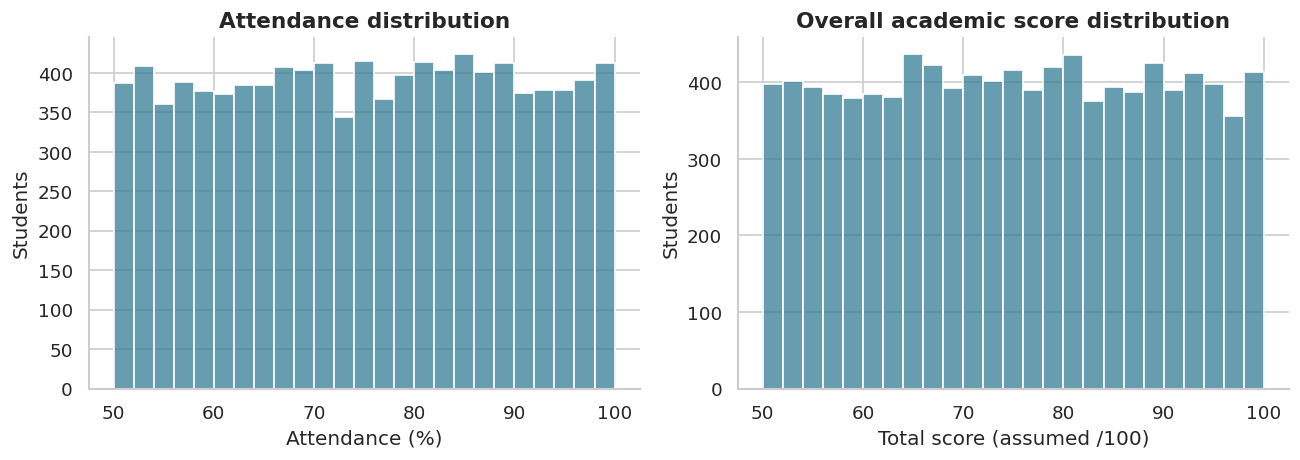

**Observation:** Median attendance is **75.31%**; median total score is **75.06**. Total scores range from **50.02 to 99.99**; a below-50 high-risk cutoff would therefore identify no students by total score alone.

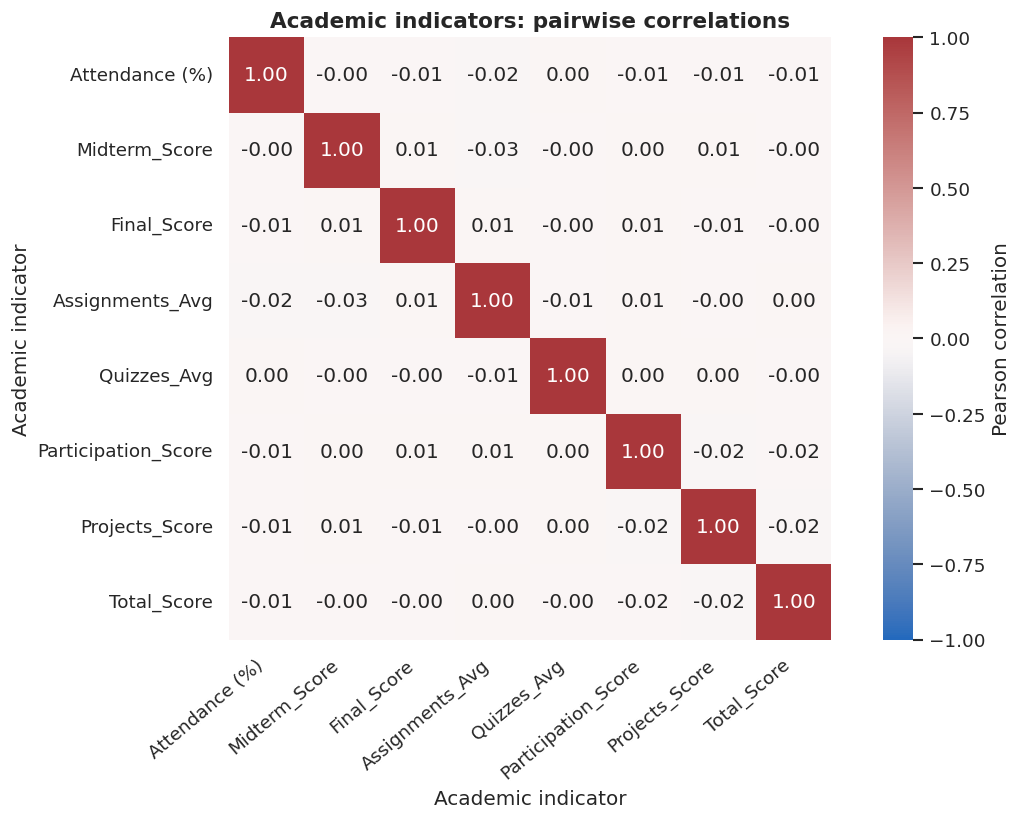

**Observation:** The largest absolute correlation of these indicators with Total_Score is **0.017**. There is little linear signal here; nonlinear prediction is still tested, not assumed.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, c, title in zip(axes, ['Attendance (%)', 'Total_Score'],
                         ['Attendance distribution', 'Overall academic score distribution']):
    sns.histplot(data=df, x=c, bins=25, ax=ax, color='#347c93')
    ax.set(title=title, xlabel='Attendance (%)' if c == 'Attendance (%)' else 'Total score (assumed /100)', ylabel='Students')
fig.tight_layout(); plt.show()
display(Markdown(f"**Observation:** Median attendance is **{df['Attendance (%)'].median():.2f}%**; "
                 f"median total score is **{df['Total_Score'].median():.2f}**. "
                 f"Total scores range from **{df['Total_Score'].min():.2f} to {df['Total_Score'].max():.2f}**; "
                 'a below-50 high-risk cutoff would therefore identify no students by total score alone.'))

academic_cols = ['Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg',
                 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score']
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[academic_cols].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1,
            cmap='vlag', center=0, square=True, ax=ax, cbar_kws={'label': 'Pearson correlation'})
ax.set(title='Academic indicators: pairwise correlations', xlabel='Academic indicator', ylabel='Academic indicator')
plt.xticks(rotation=40, ha='right'); plt.yticks(rotation=0)
fig.tight_layout(); plt.show()
strongest_corr = df[academic_cols].corr()['Total_Score'].drop('Total_Score').abs().max()
display(Markdown(f'**Observation:** The largest absolute correlation of these indicators with Total_Score is '
                 f'**{strongest_corr:.3f}**. There is little linear signal here; nonlinear prediction is still tested, not assumed.'))


## 7. Attendance vs Academic Performance
**Correlation** describes how two quantities vary together. Pearson correlation ranges from −1 to +1: +1 is a perfect positive linear relationship, −1 a perfect negative linear relationship, and 0 means no linear relationship. Near-zero correlation does not rule out every nonlinear pattern. **Correlation is not causation:** a relationship cannot by itself show that changing attendance changes marks.

Use `Total_Score` as the overall academic metric, and check `Final_Score` as a secondary comparison. Pearson correlation measures linear association; Spearman checks monotonic association. The grouped chart shows means, standard errors and sample counts: narrow differences should not be exaggerated by a truncated score axis.


**Figure 3, scatter plot:** x = attendance percentage, y = total score, one dot = one student with both values available. Transparency lets overlapping points remain visible. A rising diagonal cloud would suggest a positive relationship; the observed broad rectangular cloud does not.

**Figure 4, attendance bands:** x = attendance band, y = mean total score. Bars run from zero to avoid exaggerating small differences. The small error bars show one standard error of each mean, not the range of individual students or a 95% confidence interval. `groupby(...).agg(...)` computes counts, means and standard deviations for the bands. The result checks whether low-attendance groups actually have substantially different marks here.


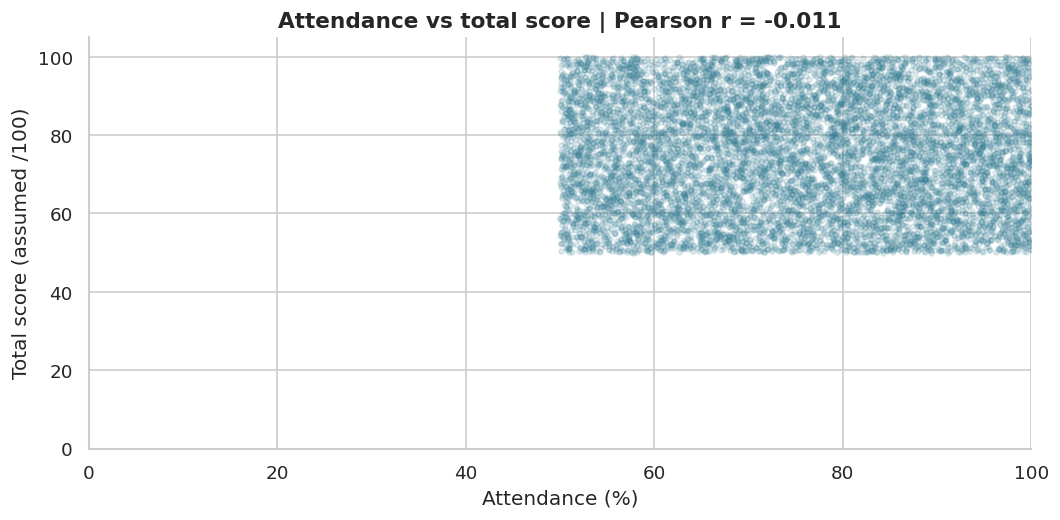

**Observation:** Across **9,798** complete pairs, Pearson r is **-0.0109** and Spearman rho is **-0.0111**. The association is very weak and negative; attendance versus Final_Score is also **-0.0123**. This does not establish causation.

,count,mean,std,SE
Attendance_group,,,,
<65%,2862,74.937,14.261,0.267
65–<75%,1974,75.458,14.433,0.325
75–<85%,1999,75.394,14.496,0.324
85–100%,2963,74.510,14.218,0.261


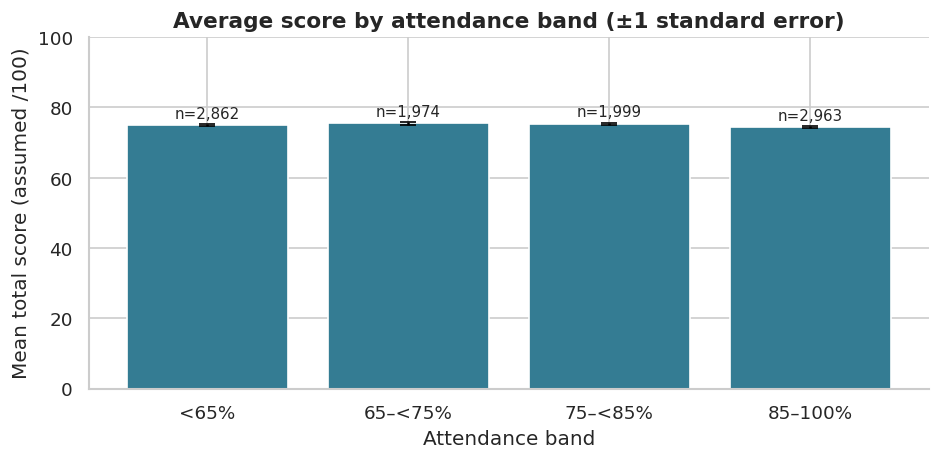

**Observation:** Band means range from **74.51** to **75.46**. Inspect these differences alongside the near-zero correlation; they do not justify claiming that attendance predicts marks well in this dataset.

In [6]:
paired = df[['Attendance (%)', 'Total_Score']].dropna()
attendance_r = paired.corr(method='pearson').iloc[0, 1]
attendance_spearman = paired.corr(method='spearman').iloc[0, 1]
final_r = df[['Attendance (%)', 'Final_Score']].corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(paired['Attendance (%)'], paired['Total_Score'], s=9, alpha=.14, color='#347c93', rasterized=True)
ax.set(title=f'Attendance vs total score | Pearson r = {attendance_r:.3f}',
       xlabel='Attendance (%)', ylabel='Total score (assumed /100)', xlim=(0, 100), ylim=(0, 105))
fig.tight_layout(); plt.show()
strength = 'very weak' if abs(attendance_r) < .2 else ('weak' if abs(attendance_r) < .4 else 'moderate or strong')
direction = 'positive' if attendance_r > 0 else 'negative'
display(Markdown(f'**Observation:** Across **{len(paired):,}** complete pairs, Pearson r is **{attendance_r:.4f}** '
                 f'and Spearman rho is **{attendance_spearman:.4f}**. The association is {strength} and {direction}; '
                 f'attendance versus Final_Score is also **{final_r:.4f}**. This does not establish causation.'))

grouped_data = paired.assign(Attendance_group=pd.cut(paired['Attendance (%)'], bins=[0, 65, 75, 85, 101],
                            right=False, labels=['<65%', '65–<75%', '75–<85%', '85–100%']))
attendance_groups = grouped_data.groupby('Attendance_group', observed=False)['Total_Score'].agg(['count', 'mean', 'std'])
attendance_groups['SE'] = attendance_groups['std'] / np.sqrt(attendance_groups['count'])
display(attendance_groups.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(attendance_groups.index.astype(str), attendance_groups['mean'],
       yerr=attendance_groups['SE'], capsize=5, color='#347c93')
ax.set(title='Average score by attendance band (±1 standard error)',
       xlabel='Attendance band', ylabel='Mean total score (assumed /100)', ylim=(0, 100))
for i, row in enumerate(attendance_groups.itertuples()):
    ax.text(i, row.mean + 2, f'n={row.count:,}', ha='center', fontsize=9)
fig.tight_layout(); plt.show()
display(Markdown(f"**Observation:** Band means range from **{attendance_groups['mean'].min():.2f}** "
                 f"to **{attendance_groups['mean'].max():.2f}**. Inspect these differences alongside the near-zero "
                 'correlation; they do not justify claiming that attendance predicts marks well in this dataset.'))


## 8. Risk Definition
Observed total scores span roughly 50–100, while recorded grades overlap across that range. Use **total-score support bands**, not unverified letter grades:

| Risk | Rule | Reason |
|---|---|---|
| High | `Total_Score < 60` | Prioritize the weakest observed overall scores for review. |
| Medium | `60 ≤ Total_Score < 75` | A middle support band below a reasonable project benchmark. |
| Low | `Total_Score ≥ 75` | Lower support priority under this project's rule. |

These are **illustrative policy thresholds, not official pass/fail rules or thresholds learned for maximum accuracy**. They are frozen before fitting any model. A score of exactly 60 is Medium; exactly 75 is Low. The benchmark 75 is a round project choice near the observed center; it needs institutional validation.

Attendance below 75% generates a separate support recommendation. It does **not** define the target, avoiding a model that simply memorizes an attendance threshold. If the true total score is already known, apply this transparent rule directly; the ML experiment estimates that eventual band from presumed earlier indicators.


**Target / label:** the answer associated with each training example. The original CSV has no risk label, so `risk_from_total()` creates it. `.apply(...)` runs that function for each total score. This makes the task supervised learning: examples contain inputs plus known project-defined answers.

**Figure 5:** x = the three risk categories, y = number of students. The labels above the bars show both counts and percentages. This reveals class imbalance: one class is more common, so an always-Low predictor can achieve considerable accuracy without finding any High-risk students.


Rows excluded from training because target is missing: 0


,Students,Percent
Risk_Level,,
Low,5010,50.10
Medium,3035,30.35
High,1955,19.55


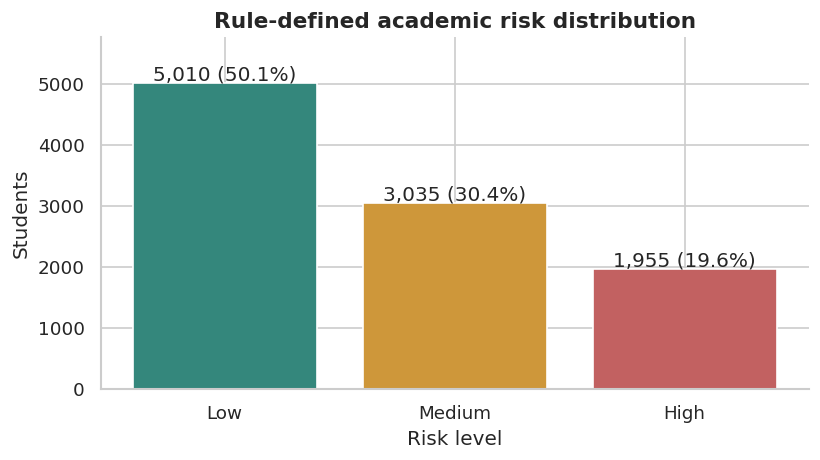

**Observation:** High risk represents **19.55%** of labeled students. Unequal class sizes make accuracy alone inadequate.

In [7]:
def risk_from_total(score):
    if pd.isna(score):
        return pd.NA
    if score < 60:
        return 'High'
    if score < 75:
        return 'Medium'
    return 'Low'
assert [risk_from_total(x) for x in [59.99, 60, 74.99, 75]] == ['High', 'Medium', 'Medium', 'Low']
df['Risk_Level'] = df['Total_Score'].apply(risk_from_total)
model_df = df.dropna(subset=['Risk_Level']).copy()
print('Rows excluded from training because target is missing:', len(df) - len(model_df))
risk_counts = model_df['Risk_Level'].value_counts().reindex(RISK_ORDER, fill_value=0)
risk_distribution = pd.DataFrame({'Students': risk_counts, 'Percent': 100 * risk_counts / risk_counts.sum()})
display(risk_distribution.round(2))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(risk_counts.index, risk_counts.values, color=RISK_COLORS)
ax.set(title='Rule-defined academic risk distribution', xlabel='Risk level', ylabel='Students')
for i, count in enumerate(risk_counts):
    ax.text(i, count + 60, f'{count:,} ({100*count/len(model_df):.1f}%)', ha='center')
ax.set_ylim(0, risk_counts.max() * 1.15)
fig.tight_layout(); plt.show()
display(Markdown(f"**Observation:** High risk represents **{risk_distribution.loc['High', 'Percent']:.2f}%** "
                 'of labeled students. Unequal class sizes make accuracy alone inadequate.'))


## 9. Feature Selection
Predict with attendance, midterm results, assignment and quiz averages, participation, and department. Treat these as **available at an intervention checkpoint**; the dataset has no timestamps to confirm that assumption. A real deployment must rebuild them using information available only before the outcome.

Exclude **Total_Score, Grade and Final_Score** (outcomes), **Projects_Score and subject scores** (timing is unclear), and names/IDs/email (identifiers). Exclude age and gender to avoid unnecessary personal characteristics, and test preparation because its timing is undocumented. Department is encoded as a category, not an ordered number. Department-specific fairness would still need review.

Data leakage means letting training see information it would not have when making a real prediction. Excluding outcomes and fitting preprocessing only on training folds addresses obvious leakage; absent timestamps and undocumented score formulas remain limitations.


**Leakage example:** a total score of 55 automatically receives High risk. If we also supplied 55 as an input, the model could rediscover the threshold instead of learning early-warning information. It is like giving someone the answer during a test. Final_Score and Grade are also excluded because they are final-outcome information; we do not claim they are numerically identical to Total_Score. Project and subject scores are excluded because their timing is unclear. The full table in section 4 documents every field.

`features` is a list of six selected input columns. `X = model_df[features]` contains the inputs; `y = model_df[target]` contains the answers. `assert` checks that no excluded column slipped into the feature list.


In [8]:
numeric_features = ['Attendance (%)', 'Midterm_Score', 'Assignments_Avg',
                    'Quizzes_Avg', 'Participation_Score']
categorical_features = ['Department']
features = numeric_features + categorical_features
target = 'Risk_Level'
excluded = set(private + ['Total_Score', 'Final_Score', 'Grade', 'Projects_Score',
                         'math_score', 'reading_score', 'writing_score', 'science_score',
                         'Age', 'Gender', 'test_preparation_course'])
assert not (set(features) & excluded)
X, y = model_df[features], model_df[target]
print('Features:', features)
print('Target:', target)


Features: ['Attendance (%)', 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Department']
Target: Risk_Level


## 10. Data Preparation for ML
Reserve 20% for final testing. The remaining 80% is the development set. Stratification preserves risk proportions. We compare models using five-fold cross-validation **inside the development set**, then evaluate the selected model once on the untouched test set.

The numeric pipeline fills missing inputs with training medians and scales them for logistic regression. The categorical pipeline fills missing categories with `Unknown` and one-hot encodes them. Unknown categories at prediction time do not crash the pipeline. Scaling is unnecessary for trees but harmless here and keeps the experiment consistent.


**Why split?** Testing only on students used during fitting would reward memorization. Our 10,000 labeled rows split into 8,000 development students and 2,000 held-out test students. `random_state=42` fixes the random choices for repeatability; 42 has no special statistical power. `stratify=y` keeps approximately the same Low/Medium/High proportions in both parts.

**Preprocessing** means preparing inputs for the algorithm. **Imputation** replaces a missing input with a reasonable stand-in: the median is the middle observed training value and is less sensitive than the mean to extreme values. `StandardScaler` subtracts the training mean and divides by the training standard deviation, so /100 marks do not automatically have a larger numerical scale than /10 participation.

**One-hot encoding example:**

| Department | Department_CS | Department_Business | Department_Engineering | Department_Mathematics |
|---|---:|---:|---:|---:|
| CS | 1 | 0 | 0 | 0 |
| Business | 0 | 1 | 0 | 0 |

These yes/no columns avoid pretending departments have ranks. `handle_unknown='ignore'` allows a new department at prediction time, encoding it with zeros in known department columns; it does not magically learn its effects.

**ColumnTransformer** sends numeric columns through imputation/scaling and the department column through imputation/encoding, then combines them. **Pipeline** chains preparation and model steps so the same transformations are used during fitting and prediction. `.fit()` learns from training data; `.predict()` applies the learned transformations and classifier to new inputs. Each cross-validation fold gets its own fitted preprocessing.


In [9]:
train_idx, test_idx = train_test_split(model_df.index, test_size=.2, random_state=SEED, stratify=y)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
assert set(train_idx).isdisjoint(test_idx)
assert set(model_df.loc[train_idx, 'Student_ID']).isdisjoint(model_df.loc[test_idx, 'Student_ID'])
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), numeric_features),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                              ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print('Development rows:', len(X_train), '| Held-out test rows:', len(X_test))
display(pd.crosstab(y, pd.Series(np.where(model_df.index.isin(train_idx), 'Development', 'Test'), index=model_df.index)))


Development rows: 8000 | Held-out test rows: 2000


col_0,Development,Test
Risk_Level,,
High,1564,391
Low,4008,1002
Medium,2428,607


## 11. Model Training
Compare logistic regression (simple linear boundaries), a shallow decision tree (interpretable rules), and a random forest (an ensemble of trees). Balanced class weights give rarer classes more influence. Fixed, modest hyperparameters avoid a costly search.

Two controls matter: a most-frequent dummy classifier shows majority-class accuracy, while a stratified random dummy gives a more useful macro-F1 baseline. **Macro metrics weight Low, Medium and High equally.** Cross-validation reports mean and variability; selection does not use test scores.


### Logistic Regression, before fitting
Despite its name, logistic regression is used here for **classification**. It learns weights for the inputs and combines them to estimate probabilities for the three categories. The largest probability determines the predicted category. It provides relatively simple boundaries and is a useful first model; no advanced mathematics is required to follow the experiment. `max_iter=2000` allows up to 2,000 solver iterations, not 2,000 students or trees.

### Decision Tree, before fitting
A tree is a learned question flowchart: for example, “Is the midterm score below a threshold?” then another question, ending in a prediction. This example describes the mechanism, not the actual fitted rules. The **root** is the first question, **branches** follow answers, and **leaves** hold class estimates. Training finds splits from data. `max_depth=5` and `min_samples_leaf=40` limit complexity so small groups cannot become very specific rules.

### Random Forest, before fitting
A forest combines many decision trees. Think of asking many slightly different advisers rather than one. Each tree is fitted to a bootstrap sample (randomly chosen training rows, with repeats allowed); at each split, it considers a random subset of features. These differences reduce the chance that every tree makes the same mistake.

**Forest = many trees. Random = randomized samples and feature choices.** The voting analogy is useful, but scikit-learn's classifier actually averages the trees' class probabilities and chooses the largest average. We use 160 trees, depth at most 7, and at least 15 rows per leaf. A forest can model nonlinear patterns but cannot create predictive information that is absent from its inputs.

### Baselines, before fitting
A **baseline** is a deliberately simple benchmark. `DummyClassifier` ignores useful feature patterns. The **most-frequent** version always predicts the largest training class (Low here); the **stratified** version makes random predictions according to training class frequencies. With roughly 50% Low, 30% Medium and 20% High, always saying Low can get about 50% accuracy while finding no High students. A complex model should justify itself against both baselines.

### Five-fold cross-validation, before fitting
Divide the development set into five groups called **folds**. Fit on four groups and validate on the remaining group; repeat five times so each group is the validation group once. For this dataset, each round uses about 6,400 development rows for fitting and 1,600 for validation. Average the five scores and show their variability. This reduces reliance on one lucky split, but the folds overlap in their training data and are not independent external studies. The 2,000 final test rows are not part of these folds.

### Metrics, before seeing results
**Illustrative numbers below are teaching examples, not this project's results.**

| Metric | Plain-English question / example |
|---|---|
| Accuracy | How many predictions were correct overall? 80 correct out of 100 gives 80%. |
| High precision | Of the students flagged High, how many really have a High label? If 6 of 10 flags are correct: 60%. |
| High recall | Of all actual High students, how many were found? If 6 of 12 are found: 50%. |
| F1 | Balance precision and recall; 60% precision and 50% recall gives approximately 54.5%, using `2 × P × R / (P + R)`. |
| Macro F1 | Compute F1 for each class, then average the three equally. It keeps the smaller High class important. |
| Weighted F1 | Average class F1 scores using actual class sizes as weights, so the larger Low class matters more. |

The comparison's precision and recall are **macro averages**, not High-only measures. A confusion matrix counts each true/predicted combination; section 13 will read it in detail. `zero_division=0` assigns zero when a class receives no predictions rather than dividing by zero. Balanced training weights, stratified splits and macro metrics solve different problems: training influence, split proportions and evaluation weighting, respectively.


In [10]:
estimators = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=40,
                                           class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=160, max_depth=7, min_samples_leaf=15,
                                            class_weight='balanced', random_state=SEED, n_jobs=1),
    'Dummy (majority)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Dummy (stratified)': DummyClassifier(strategy='stratified', random_state=SEED)
}
pipelines = {name: Pipeline([('preprocess', clone(preprocessor)), ('model', estimator)])
             for name, estimator in estimators.items()}
# Explicit callables keep multiclass scoring independent of binary positive-label defaults.
def macro_precision(estimator, values, labels):
    return precision_score(labels, estimator.predict(values), average='macro', zero_division=0)
def macro_recall(estimator, values, labels):
    return recall_score(labels, estimator.predict(values), average='macro', zero_division=0)
def macro_f1(estimator, values, labels):
    return f1_score(labels, estimator.predict(values), average='macro', zero_division=0)
def weighted_f1(estimator, values, labels):
    return f1_score(labels, estimator.predict(values), average='weighted', zero_division=0)
scoring = {'Accuracy': 'accuracy', 'Precision': macro_precision,
           'Recall': macro_recall, 'F1 Score': macro_f1, 'Weighted F1': weighted_f1}
comparison_rows = []
for name, pipeline in pipelines.items():
    result = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1, error_score='raise')
    row = {'Model': name}
    row.update({metric: result['test_' + metric].mean() for metric in scoring})
    row['F1 SD'] = result['test_F1 Score'].std(ddof=1)
    comparison_rows.append(row)
comparison = pd.DataFrame(comparison_rows).set_index('Model').sort_values('F1 Score', ascending=False)
display(comparison.rename(columns={'Precision': 'Precision (macro)', 'Recall': 'Recall (macro)', 'F1 Score': 'Macro F1'}).round(4))


,Accuracy,Precision (macro),Recall (macro),Macro F1,Weighted F1,F1 SD
Model,,,,,,
Dummy (stratified),0.3881,0.3416,0.3415,0.3415,0.3885,0.0130
Random Forest,0.3530,0.3434,0.3441,0.3351,0.3623,0.0157
Logistic Regression,0.3089,0.3260,0.3267,0.3025,0.3126,0.0108
Decision Tree,0.2896,0.3309,0.3374,0.2785,0.2652,0.0369
Dummy (majority),0.5010,0.1670,0.3333,0.2225,0.3344,0.0001


## 12. Model Comparison
Choose the highest cross-validation macro-F1 **among the three requested ML models**. The dummy baselines remain a usefulness check, not a reason to pretend the selected classifier is deployment-ready. Differences of a few thousandths with overlapping fold variability are not strong evidence of superiority.


**Figure 6:** y = model name; x = average development macro F1, on a 0–1 scale; whiskers = one standard deviation across validation folds. Higher is better for this metric. These whiskers describe fold variability, not a formal confidence interval. The table also contains accuracy, macro precision/recall and weighted F1 for all five methods.

“Selected ML model” means best of the three requested learned classifiers, not necessarily best of all five methods. If a dummy does better, that limits the usefulness of the selected ML model. The report still demonstrates the selected ML pipeline transparently.


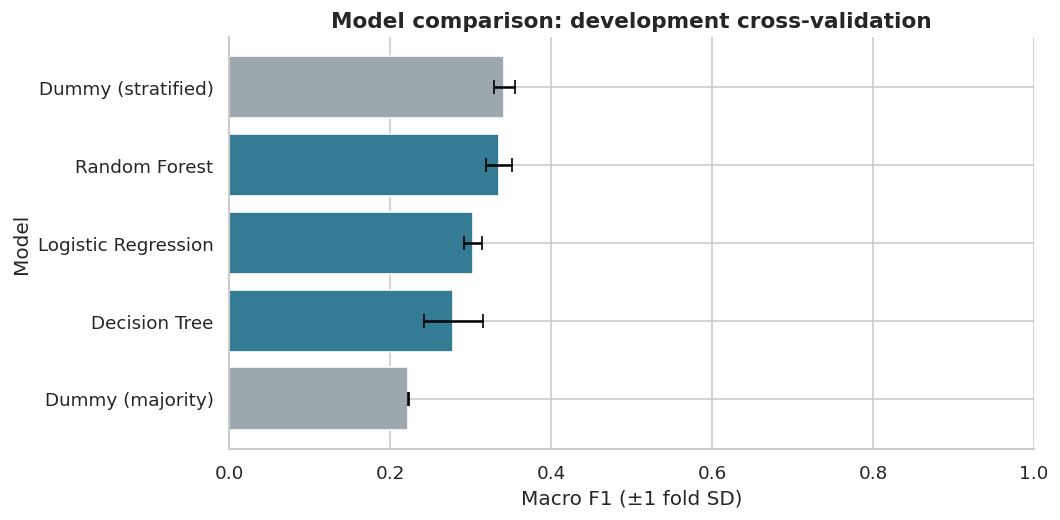

**Observation:** **Random Forest** has the highest mean macro-F1 among the requested models (**0.3351**); the stratified dummy scores **0.3415**. The difference is **-0.0065**, so baseline comparison and fold variability must accompany any claim about usefulness.

In [11]:
ml_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
best_name = comparison.loc[ml_names, 'F1 Score'].idxmax()
selected_pipeline = clone(pipelines[best_name])
selected_pipeline.fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = comparison.sort_values('F1 Score')
ax.barh(ordered.index, ordered['F1 Score'], xerr=ordered['F1 SD'], capsize=4,
        color=['#9ca8ad' if 'Dummy' in name else '#347c93' for name in ordered.index])
ax.set(title='Model comparison: development cross-validation', xlabel='Macro F1 (±1 fold SD)', ylabel='Model', xlim=(0, 1))
fig.tight_layout(); plt.show()
best_cv = comparison.loc[best_name, 'F1 Score']
random_cv = comparison.loc['Dummy (stratified)', 'F1 Score']
display(Markdown(f'**Observation:** **{best_name}** has the highest mean macro-F1 among the requested models '
                 f'(**{best_cv:.4f}**); the stratified dummy scores **{random_cv:.4f}**. '
                 f'The difference is **{best_cv-random_cv:+.4f}**, so baseline comparison and fold variability '
                 'must accompany any claim about usefulness.'))


## 13. Model Evaluation
Now use the held-out test set. Precision asks how often a predicted class is correct; recall asks how many actual members of that class we found; F1 balances both. Support is the number of actual examples. In the confusion matrix, rows are true labels and columns are predictions; the diagonal contains correct classifications.

For intervention, missed High-risk students matter. We show High recall and how many High students were incorrectly labeled Low. Test results are not used to change the model or its hyperparameters.


**Figure 7:** rows = rule-defined (actual) category; columns = predicted category. For High-risk precision, divide the bottom-right cell by the entire High-prediction column. For High-risk recall, divide it by the entire actual-High row. The diagonal sum divided by the whole matrix is accuracy. A High-to-Low error is a missed support flag, while a Low-to-High error can create unnecessary review work.

“Actual” here means actual **project-defined label**, not clinically or institutionally verified risk. The printed classification report shows per-class precision, recall, F1 and support. Its weighted average is useful for overall distribution but can conceal a weak smaller class.


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Random Forest,0.3325,0.327,0.328,0.3165,0.3402


              precision    recall  f1-score   support

         Low     0.4867    0.3114    0.3798      1002
      Medium     0.3112    0.4168    0.3563       607
        High     0.1832    0.2558    0.2134       391

    accuracy                         0.3325      2000
   macro avg     0.3270    0.3280    0.3165      2000
weighted avg     0.3741    0.3325    0.3402      2000



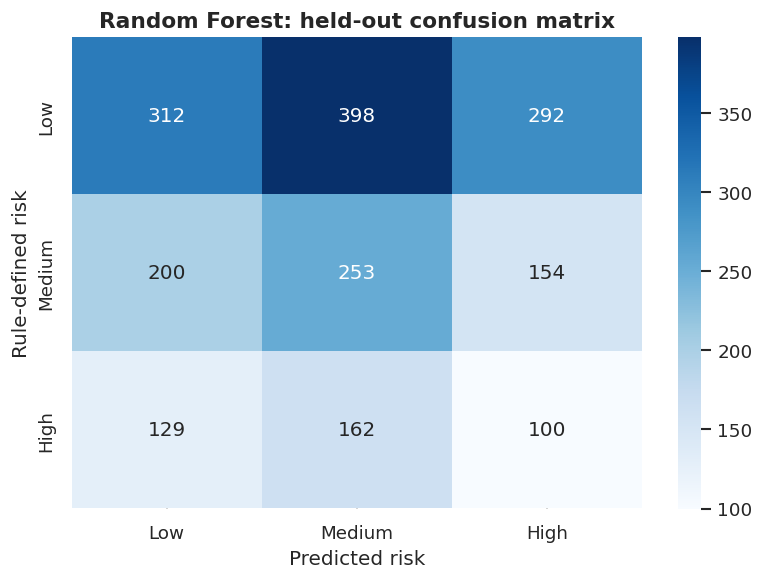

**Observation:** The model identifies **100 of 391** High-risk students (**25.6% recall**), missing **291**; **129** are labeled Low. Predictions must not be used to deny support.

,Model,Accuracy,Precision (macro),Recall (macro),Macro F1,Weighted F1
0,Dummy (majority),0.5010,0.1670,0.3333,0.2225,0.3344
1,Dummy (stratified),0.3895,0.3444,0.3444,0.3444,0.3898


In [12]:
y_pred = selected_pipeline.predict(X_test)
test_metrics = {'Accuracy': accuracy_score(y_test, y_pred),
                'Precision (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
                'Recall (macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
                'F1 (macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)}
test_metrics['F1 (weighted)'] = f1_score(y_test, y_pred, average='weighted', zero_division=0)
display(pd.DataFrame([test_metrics], index=[best_name]).round(4))
print(classification_report(y_test, y_pred, labels=RISK_ORDER, digits=4, zero_division=0))
class_metrics = classification_report(y_test, y_pred, labels=RISK_ORDER, output_dict=True, zero_division=0)
cm = confusion_matrix(y_test, y_pred, labels=RISK_ORDER)
fig, ax = plt.subplots(figsize=(6.8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=RISK_ORDER, yticklabels=RISK_ORDER, ax=ax)
ax.set(title=f'{best_name}: held-out confusion matrix', xlabel='Predicted risk', ylabel='Rule-defined risk')
fig.tight_layout(); plt.show()
high_recall = class_metrics['High']['recall']
high_total = int(cm[2].sum())
display(Markdown(f'**Observation:** The model identifies **{cm[2,2]} of {high_total}** High-risk students '
                 f'(**{high_recall:.1%} recall**), missing **{high_total-cm[2,2]}**; **{cm[2,0]}** are labeled Low. '
                 'Predictions must not be used to deny support.'))
baseline_test = []
for name in ['Dummy (majority)', 'Dummy (stratified)']:
    baseline = clone(pipelines[name]).fit(X_train, y_train)
    pred = baseline.predict(X_test)
    baseline_test.append({'Model': name, 'Accuracy': accuracy_score(y_test, pred),
                          'Precision (macro)': precision_score(y_test, pred, average='macro', zero_division=0),
                          'Recall (macro)': recall_score(y_test, pred, average='macro', zero_division=0),
                          'Macro F1': f1_score(y_test, pred, average='macro', zero_division=0),
                          'Weighted F1': f1_score(y_test, pred, average='weighted', zero_division=0)})
display(pd.DataFrame(baseline_test).round(4))


## 14. Feature Importance / Model Interpretation
Permutation importance shuffles one original input column at a time and measures the drop in held-out macro-F1. It works with any selected model and keeps department as one interpretable feature. This is post-evaluation diagnosis, not a feature-selection step. Near-zero or negative importance suggests no reliable contribution, not a protective effect.

For completeness, also show the fitted model's native importance or class-specific logistic coefficients using the actual transformed column names. Those describe the fitted model; they do not establish causality.



**Figure 8:** y = original input field; x = decrease in test macro F1 when that field is randomly shuffled, with variability across repeated shuffles. A clearly positive decrease suggests the model benefited from that field; near-zero/negative values do not demonstrate useful signal. Negative values mean shuffling happened to improve the measured score. The separate native tree-importance table measures how much fields reduced impurity during training and can show nonzero weights even for an unhelpful model. Neither measure proves that changing a feature causes an outcome.


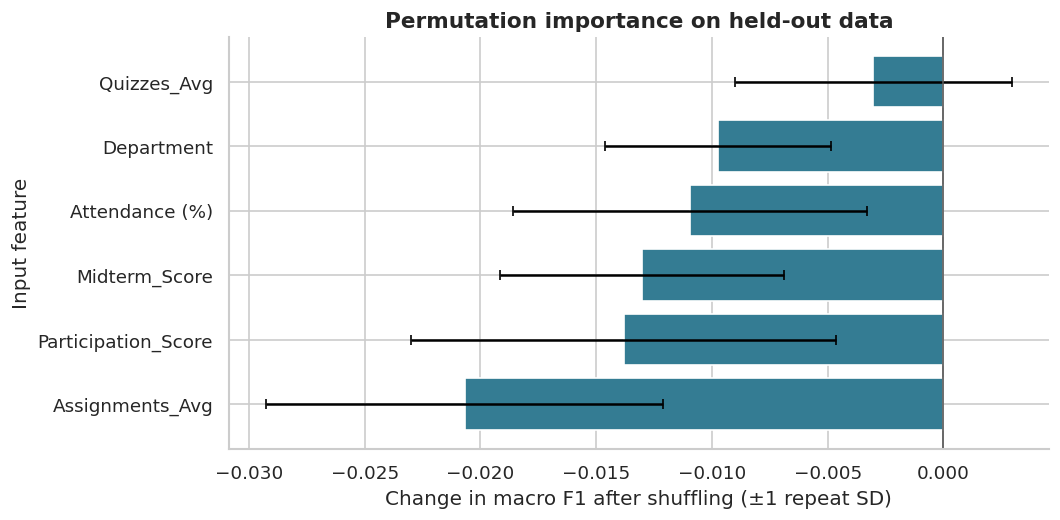

**Observation:** The largest estimated decrease is for **Quizzes_Avg** (**-0.0030**, repeat SD **0.0060**). Interpret this alongside the weak predictive performance; it is not proof of an influential real-world cause.

,Transformed feature,Tree importance
3,numeric__Quizzes_Avg,0.2096
1,numeric__Midterm_Score,0.1990
2,numeric__Assignments_Avg,0.1886
4,numeric__Participation_Score,0.1784
0,numeric__Attendance (%),0.1748
6,categorical__Department_CS,0.0181
7,categorical__Department_Engineering,0.0144
5,categorical__Department_Business,0.0126
8,categorical__Department_Mathematics,0.0044


**All permutation means are non-positive in this run.** Shuffling did not lower macro F1 on average; no reliably useful predictor is demonstrated by this analysis.

In [13]:
permutation = permutation_importance(selected_pipeline, X_test, y_test,
                                    scoring=scoring['F1 Score'], n_repeats=8,
                                    random_state=SEED, n_jobs=1)
importance = pd.DataFrame({'Feature': features, 'Mean F1 decrease': permutation.importances_mean,
                           'SD': permutation.importances_std}).sort_values('Mean F1 decrease')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(importance['Feature'], importance['Mean F1 decrease'], xerr=importance['SD'], capsize=3, color='#347c93')
ax.axvline(0, color='#555555', linewidth=1)
ax.set(title='Permutation importance on held-out data', xlabel='Change in macro F1 after shuffling (±1 repeat SD)', ylabel='Input feature')
fig.tight_layout(); plt.show()
top_feature = importance.iloc[-1]
display(Markdown(f"**Observation:** The largest estimated decrease is for **{top_feature['Feature']}** "
                 f"(**{top_feature['Mean F1 decrease']:.4f}**, repeat SD **{top_feature['SD']:.4f}**). "
                 'Interpret this alongside the weak predictive performance; it is not proof of an influential real-world cause.'))
transformed_names = selected_pipeline.named_steps['preprocess'].get_feature_names_out()
fitted_estimator = selected_pipeline.named_steps['model']
if hasattr(fitted_estimator, 'feature_importances_'):
    native_importance = pd.DataFrame({'Transformed feature': transformed_names,
                                     'Tree importance': fitted_estimator.feature_importances_})
    display(native_importance.sort_values('Tree importance', ascending=False).head(10).round(4))
else:
    coefficients = pd.DataFrame(fitted_estimator.coef_.T, index=transformed_names, columns=fitted_estimator.classes_)
    display(coefficients.round(4))
    display(Markdown('Positive coefficients increase a class logit relative to the other logits. Numerical inputs are standardized. '
                     'Coefficients are model parameters, not causal effects.'))

if (importance['Mean F1 decrease'] <= 0).all():
    display(Markdown('**All permutation means are non-positive in this run.** Shuffling did not lower macro F1 on average; no reliably useful predictor is demonstrated by this analysis.'))


## 15. Student Risk Prediction
The reusable function accepts a dictionary using the listed feature names, plus an optional anonymous student label. Final marks are **not required** and never enter the model. Missing inputs use the same fitted training imputer; invalid values are treated as missing and flagged. An entirely empty record is rejected.

`Academic Indicator` is the observed midterm score, not the final total. `Max Model Probability` is an uncalibrated model output, **not a guarantee of correctness**. The function is demonstrated after the recommendation helper is defined in the next section.


**Follow the function:** `prepare_student()` turns the dictionary into a one-row table and checks ranges; `selected_pipeline.predict(row)` returns Low/Medium/High; `.predict_proba(row)` provides class probabilities; `recommend(...)` builds the advice; `return {...}` packages the result as a dictionary. The recommendation function is defined in the next code cell before we actually call the predictor.

An actual held-out row can be demonstrated with:
```python
student_data = X_test.iloc[0].to_dict()
predict_student_risk(student_data, student_label="Demo student")
```
This uses a real row rather than inventing a score or a result. The next section shows examples for all three actual classes and, when present, all three predicted classes.


In [14]:
def prepare_student(student):
    if not isinstance(student, dict):
        raise TypeError('Provide a dictionary of student features.')
    canonical = {COLUMN_MAP.get(key(k), k): v for k, v in student.items()}
    row = pd.DataFrame([{c: canonical.get(c, np.nan) for c in features}])
    notes = []
    for c in numeric_features:
        value = row.at[0, c]
        parsed = pd.to_numeric(str(value).replace('%', '').strip(), errors='coerce')
        lo, hi = BOUNDS[c]
        if pd.isna(parsed) or not lo <= parsed <= hi:
            row.at[0, c] = np.nan
            notes.append(c + ' missing/invalid')
        else:
            row.at[0, c] = float(parsed)
    department = row.at[0, 'Department']
    if pd.isna(department) or not str(department).strip():
        row.at[0, 'Department'] = np.nan
        notes.append('Department missing')
    else:
        cleaned = str(department).strip().lower()
        row.at[0, 'Department'] = department_map.get(cleaned, str(department).strip())
        if row.at[0, 'Department'] not in set(X_train['Department'].dropna()):
            notes.append('Unseen department; encoded as unknown')
    if row[numeric_features].isna().all(axis=None):
        raise ValueError('At least one valid academic/attendance input is required.')
    return row, notes

def predict_student_risk(student, student_label='New student'):
    row, notes = prepare_student(student)
    risk = selected_pipeline.predict(row)[0]
    probability = selected_pipeline.predict_proba(row).max()
    return {'Student': student_label, 'Attendance (%)': row.iloc[0]['Attendance (%)'],
            'Academic Indicator (Midterm)': row.iloc[0]['Midterm_Score'],
            'Predicted Risk': risk, 'Max Model Probability': round(float(probability), 4),
            'Recommendation': recommend(row.iloc[0], risk),
            'Data Quality Note': '; '.join(notes) if notes else 'Observed inputs complete'}


## 16. Recommendation System
Recommendations are transparent support suggestions, not ML-generated text. The attendance benchmark of 75%, assessment benchmark of 60/100, and participation benchmark of 4/10 are project assumptions, not university regulations. Missing observations trigger data verification rather than a claim that a student performed poorly. A Low prediction never overrides a visible weakness.


**Two separate systems:** the fitted ML model predicts risk from learned relationships; the recommendation function uses ordinary Python `if` conditions written by us. Advice is not proof that the prediction is correct. A student predicted Low can still receive an attendance recommendation if attendance is below 75%. The sample table displays true and predicted labels side by side so errors remain visible.


In [15]:
def recommend(row, risk):
    tips = []
    if pd.notna(row['Attendance (%)']) and row['Attendance (%)'] < 75:
        tips.append('Improve attendance and attend classes consistently.')
    if pd.notna(row['Midterm_Score']) and row['Midterm_Score'] < 60:
        tips.append('Revise weak topics and focus on upcoming assessments.')
    if any(pd.notna(row[c]) and row[c] < 60 for c in ['Assignments_Avg', 'Quizzes_Avg']):
        tips.append('Increase practice and complete assignments regularly.')
    if pd.notna(row['Participation_Score']) and row['Participation_Score'] < 4:
        tips.append('Seek clarification and participate more actively in class.')
    if any(pd.isna(row[c]) for c in features):
        tips.append('Verify missing input data before deciding on support.')
    if risk == 'High':
        tips.append('Arrange an adviser review; confirm the model flag with current assessments.')
    elif risk == 'Medium':
        tips.append('Review progress at the next assessment.')
    elif not tips:
        tips.append('Maintain current performance and consistent study habits.')
    return ' '.join(tips)

# Choose actual held-out examples by TRUE band; show errors rather than hiding them.
sample_outputs = []
for label in RISK_ORDER:
    idx = y_test[y_test.eq(label)].index[0]
    result = predict_student_risk(X_test.loc[idx].to_dict(), model_df.loc[idx, 'Student'])
    result['Rule-defined Risk'] = label
    result['Observed Total_Score (reference only)'] = model_df.loc[idx, 'Total_Score']
    sample_outputs.append(result)
sample_table = pd.DataFrame(sample_outputs)
display(sample_table)
print('Examples represent one actual Low, Medium and High student, not necessarily correct predictions.')
# Also show one actual row per predicted class whenever that class is predicted.
predicted_examples = []
for label in RISK_ORDER:
    positions = np.flatnonzero(y_pred == label)
    if len(positions):
        idx = X_test.index[positions[0]]
        predicted_examples.append(predict_student_risk(X_test.loc[idx].to_dict(), model_df.loc[idx, 'Student']))
    else:
        print('No held-out student was predicted', label)
display(pd.DataFrame(predicted_examples))

# Verify robustness on a copy of a real record, not a fabricated performance result.
probe = X_test.iloc[0].to_dict()
probe['Attendance (%)'] = 135
probe['Department'] = 'Unseen department'
probe_result = predict_student_risk(probe)
assert pd.isna(probe_result['Attendance (%)'])
assert 'Unseen' in probe_result['Data Quality Note']
try:
    predict_student_risk({})
except ValueError:
    print('Validation passed: empty input is rejected; invalid attendance and unseen categories are handled.')
else:
    raise AssertionError('Empty input should fail validation.')


,Student,Attendance (%),Academic Indicator (Midterm),Predicted Risk,Max Model Probability,Recommendation,Data Quality Note,Rule-defined Risk,Observed Total_Score (reference only)
0,Student 05575,83.87,71.77,High,0.3395,Arrange an adviser review; confirm the model flag with current assessments.,Observed inputs complete,Low,85.82
1,Student 06285,91.50,91.36,Medium,0.3510,Increase practice and complete assignments regularly. Review progress at the next assessment.,Observed inputs complete,Medium,70.69
2,Student 07480,68.65,78.28,Low,0.3429,Improve attendance and attend classes consistently.,Observed inputs complete,High,54.61


Examples represent one actual Low, Medium and High student, not necessarily correct predictions.


,Student,Attendance (%),Academic Indicator (Midterm),Predicted Risk,Max Model Probability,Recommendation,Data Quality Note
0,Student 07480,68.65,78.28,Low,0.3429,Improve attendance and attend classes consistently.,Observed inputs complete
1,Student 06285,91.50,91.36,Medium,0.3510,Increase practice and complete assignments regularly. Review progress at the next assessment.,Observed inputs complete
2,Student 05575,83.87,71.77,High,0.3395,Arrange an adviser review; confirm the model flag with current assessments.,Observed inputs complete


Validation passed: empty input is rejected; invalid attendance and unseen categories are handled.


## 17. Automated Risk Report
Generate one row per cleaned student. To avoid misleadingly optimistic in-sample predictions, development students receive **out-of-fold predictions**: the corresponding model did not train on that row. Test students receive predictions from the selected development-trained pipeline. The method is recorded per row. Selection used the development set, so its out-of-fold results are not an independent final evaluation; only the held-out test metrics are reported as final performance.

The CSV includes both predicted risk and the observed rule-defined band for audit. Final total score is included only as a clearly labeled reference column, never as an ML input. Anonymous row labels replace names, email and source IDs. Blank measured values stay blank; imputation happens only inside the model.


**How export works:** create a DataFrame with one row per cleaned record, attach predictions, run the recommendation function for each row, then call `to_csv(..., index=False)`. `index=False` avoids exporting an extra internal row-number column. Model inputs and missing values are handled inside the pipeline; the CSV retains missing observed values as blanks.

| Export column | Meaning |
|---|---|
| Student | Anonymous row label; stable for this dataset/order, not the original Student_ID. |
| Attendance (%) | Cleaned observed attendance; blank if missing or invalid. |
| Academic Indicator (Midterm) | Cleaned midterm mark; an input available before the final outcome by assumption. |
| Observed Total_Score (reference only) | Final overall score retained for audit, never used as an input. |
| Rule-defined Risk | Band computed directly from that observed total. |
| Predicted Risk | ML estimate, which can disagree with the observed band. |
| Prediction Method | Out-of-fold development prediction or held-out test prediction. |
| Recommendation | Transparent rule-based support suggestions. |
| Missing Model Inputs | Number of unavailable model inputs in this record. |
| Data Quality Note | Reminder that missing/invalid values need verification. |

The export has 10,000 records after deduplication. For a real operational roster, identity mapping would need to be retained securely by authorized staff; this shareable report deliberately contains no names or email addresses.


In [16]:
oof_predictions = cross_val_predict(clone(pipelines[best_name]), X_train, y_train, cv=cv, method='predict', n_jobs=1)
report = df[['Student', 'Attendance (%)', 'Midterm_Score', 'Total_Score', 'Risk_Level']].rename(
    columns={'Midterm_Score': 'Academic Indicator (Midterm)',
             'Total_Score': 'Observed Total_Score (reference only)', 'Risk_Level': 'Rule-defined Risk'}).copy()
report['Predicted Risk'] = pd.Series(index=df.index, dtype='object')
report['Prediction Method'] = pd.Series(index=df.index, dtype='object')
report.loc[train_idx, 'Predicted Risk'] = oof_predictions
report.loc[train_idx, 'Prediction Method'] = 'Out-of-fold development prediction'
report.loc[test_idx, 'Predicted Risk'] = y_pred
report.loc[test_idx, 'Prediction Method'] = 'Held-out test prediction'
unlabeled_idx = df.index[df['Risk_Level'].isna()]
if len(unlabeled_idx):
    report.loc[unlabeled_idx, 'Predicted Risk'] = selected_pipeline.predict(df.loc[unlabeled_idx, features])
    report.loc[unlabeled_idx, 'Prediction Method'] = 'Unlabeled record: development-trained model'
report['Recommendation'] = [recommend(df.loc[i], report.loc[i, 'Predicted Risk']) for i in report.index]
report['Missing Model Inputs'] = df[features].isna().sum(axis=1)
report['Data Quality Note'] = np.where(report['Missing Model Inputs'] > 0,
                                     'Missing/invalid values imputed inside model; verify source data', 'Observed model inputs complete')
report_path = Path('student_risk_report.csv')
report.to_csv(report_path, index=False)
display(report.head(10))
print('Saved:', report_path.name, '| Student rows:', len(report))
display(FileLink(str(report_path)))
# Offer a download in Colab; local Jupyter users can use the file link above.
try:
    from google.colab import files
except ImportError:
    pass
else:
    files.download(str(report_path))

# Integrity checks directly address report correctness and leakage risks.
reloaded_report = pd.read_csv(report_path)
assert len(reloaded_report) == len(df) and reloaded_report['Student'].is_unique
assert reloaded_report['Predicted Risk'].isin(RISK_ORDER).all()
assert reloaded_report['Recommendation'].notna().all()
assert not set(private).intersection(reloaded_report.columns)
assert len(oof_predictions) == len(train_idx)
assert not set(features).intersection(excluded)
assert int(cm.sum()) == len(y_test)
print('Report and split integrity checks passed.')


,Student,Attendance (%),Academic Indicator (Midterm),Observed Total_Score (reference only),Rule-defined Risk,Predicted Risk,Prediction Method,Recommendation,Missing Model Inputs,Data Quality Note
0,Student 00001,52.29,55.03,56.09,High,Medium,Out-of-fold development prediction,Improve attendance and attend classes consistently. Revise weak topics and focus on upcoming assessments. Seek clarification and participate more actively in class. Review progress at the next assessment.,0,Observed model inputs complete
1,Student 00002,97.27,97.23,50.64,High,Medium,Held-out test prediction,Review progress at the next assessment.,0,Observed model inputs complete
2,Student 00003,57.19,67.05,70.30,Medium,High,Out-of-fold development prediction,Improve attendance and attend classes consistently. Arrange an adviser review; confirm the model flag with current assessments.,0,Observed model inputs complete
3,Student 00004,95.15,47.79,61.63,Medium,Medium,Out-of-fold development prediction,Revise weak topics and focus on upcoming assessments. Review progress at the next assessment.,0,Observed model inputs complete
4,Student 00005,54.18,46.59,66.13,Medium,Medium,Out-of-fold development prediction,Improve attendance and attend classes consistently. Revise weak topics and focus on upcoming assessments. Review progress at the next assessment.,0,Observed model inputs complete
5,Student 00006,81.08,78.85,62.08,Medium,Low,Out-of-fold development prediction,Increase practice and complete assignments regularly.,0,Observed model inputs complete
6,Student 00007,57.60,66.26,83.21,Low,Medium,Out-of-fold development prediction,Improve attendance and attend classes consistently. Seek clarification and participate more actively in class. Review progress at the next assessment.,0,Observed model inputs complete
7,Student 00008,51.91,45.67,81.93,Low,Medium,Held-out test prediction,Improve attendance and attend classes consistently. Revise weak topics and focus on upcoming assessments. Seek clarification and participate more actively in class. Review progress at the next assessment.,0,Observed model inputs complete
8,Student 00009,85.97,84.42,95.62,Low,Low,Out-of-fold development prediction,Increase practice and complete assignments regularly. Seek clarification and participate more actively in class.,0,Observed model inputs complete
9,Student 00010,64.01,87.96,84.99,Low,Low,Out-of-fold development prediction,Improve attendance and attend classes consistently. Increase practice and complete assignments regularly.,0,Observed model inputs complete


Saved: student_risk_report.csv | Student rows: 10000


student_risk_report.csv

Report and split integrity checks passed.


## 18. Key Insights and Conclusion
The following observations are calculated from the executed analysis. No performance values are hardcoded.


In [17]:
invalid_total = sum(row['Invalid set to missing'] for row in invalid_audit)
insights = [
    f'**Data quality:** {len(raw):,} source rows became {len(df):,} unique student records after removing {duplicate_count} exact duplicates. {invalid_total} out-of-range numeric entries were converted to missing values.',
    f'**Attendance:** Pearson correlation with Total_Score is {attendance_r:.4f} across {len(paired):,} observed pairs; this offers little evidence of a useful linear relationship.',
    f'**Risk mix:** High {risk_distribution.loc["High", "Percent"]:.2f}%, Medium {risk_distribution.loc["Medium", "Percent"]:.2f}%, Low {risk_distribution.loc["Low", "Percent"]:.2f}%. These describe the chosen policy, not confirmed intervention needs.',
    f'**Model selection:** {best_name} led the three ML candidates on development macro-F1 ({best_cv:.4f}), versus {random_cv:.4f} for the stratified dummy. Held-out accuracy is {test_metrics["Accuracy"]:.4f} and macro-F1 is {test_metrics["F1 (macro)"]:.4f}.',
    f'**Important failure:** High-risk recall is {high_recall:.2%}; {high_total-cm[2,2]} of {high_total} High students were missed. Automatic intervention decisions are not justified.',
    f'**Interpretation and delivery:** The largest permutation importance belongs to {top_feature["Feature"]} ({top_feature["Mean F1 decrease"]:.4f} F1 decrease), which must be interpreted cautiously. The report contains {len(report):,} rows with recommendations and prediction provenance.'
]
for insight in insights:
    display(Markdown('- ' + insight))


- **Data quality:** 10,030 source rows became 10,000 unique student records after removing 30 exact duplicates. 8 out-of-range numeric entries were converted to missing values.

- **Attendance:** Pearson correlation with Total_Score is -0.0109 across 9,798 observed pairs; this offers little evidence of a useful linear relationship.

- **Risk mix:** High 19.55%, Medium 30.35%, Low 50.10%. These describe the chosen policy, not confirmed intervention needs.

- **Model selection:** Random Forest led the three ML candidates on development macro-F1 (0.3351), versus 0.3415 for the stratified dummy. Held-out accuracy is 0.3325 and macro-F1 is 0.3165.

- **Important failure:** High-risk recall is 25.58%; 291 of 391 High students were missed. Automatic intervention decisions are not justified.

- **Interpretation and delivery:** The largest permutation importance belongs to Quizzes_Avg (-0.0030 F1 decrease), which must be interpreted cautiously. The report contains 10,000 rows with recommendations and prediction provenance.

### Limitations
- Labels are score-policy bands, not observed failures, dropout events or validated support needs. Different thresholds change the problem.
- The CSV has no supplied provenance documentation, assessment timestamps or total-score formula. Weak relationships and inconsistent grades are data-quality concerns; they do not prove a synthetic origin.
- Initial schema and distribution inspection covered the supplied data. Thresholds were fixed before model fitting and not tuned to test performance; this is an educational holdout evaluation, not a preregistered external validation.
- Same-student duplicates are excluded, and obvious outcome leakage is blocked. Without timestamps, availability of the chosen “early” features cannot be guaranteed.
- A random split within one dataset cannot establish performance at another institution or in a future cohort. Factors such as illness, financial pressure, teaching conditions and access to support are absent.
- Weak performance and baseline comparisons limit practical usefulness. Model feature importance is not a causal explanation. We have not validated fairness across departments or calibrated probabilities.
- Missing input values are approximated by training medians. Human review should verify source data and consider the student's circumstances.

### Conclusion
The selected ML model did not outperform the stratified random baseline on development macro-F1. It is retained as an experimental comparison, not recommended for operational use.

The project inspects and cleans the actual dataset, studies attendance versus marks, defines transparent support bands, compares logistic regression, a decision tree and a random forest, and produces predictions, recommendations and an automated CSV report. The key lesson is that a correct ML workflow can expose a dataset's lack of predictive signal. Use known scores for direct rule-based support screening; do not present the experimental classifier as a reliable intervention system.

### Interview quick reference
- **Why a pipeline?** It learns imputation, scaling and encoding on training data and applies the same steps at prediction time.
- **Why not use total score as an input?** It defines the label; giving it to the model would reveal the answer.
- **Why cross-validation plus a test set?** Cross-validation chooses the model; the reserved test set checks that choice on unseen students.
- **Why macro F1?** Each risk group matters, even when group sizes differ.
- **Why a dummy baseline?** A sophisticated-looking model must demonstrate value beyond a trivial guessing strategy.
- **What would improve this?** Verified, timestamped early assessments, an institution-approved outcome definition, external validation and staff review of support recommendations.
